# Transfer Learning

The goal of transfer learning is to leverage knowledge from a model pre-trained on a large dataset and apply it to a new, often smaller, dataset.

This approach benefits from the fact that the feature extraction layers have already learned useful representations. As a result, training is typically faster and the resulting model often performs better, even with limited data.

Most pre-trained models are structured in blocks. At a high level (and in simplified terms), the early blocks act as feature extractors, capturing patterns such as edges, textures, and shapes. These features are passed through successive layers until they reach the final block, which performs the classification.

Many of these models have been trained on the ImageNet-1K dataset, and their pretrained weights are readily available in torchvision. 

Historically, the notion of transferring knowledge across tasks appears in earlier work on inductive transfer and self‑taught learning. Early work such as Raina et al., “Self-taught learning: transfer learning from unlabeled data” (ICML 2007) ([PDF](https://dl.acm.org/doi/epdf/10.1145/1273496.1273592)) showed that features learned on large collections of unlabeled images can be transferred to improve supervised classification on new tasks, helping to establish transfer learning as a practical paradigm.

In this notebook we focus on inductive transfer learning, where we do have labeled data for the target task and want to train a classifier specifically for that task. Concretely, we use parameter transfer: we start from a convolutional network pretrained on a large source task (ImageNet), keep most of its weights as a generic visual feature extractor, and only replace and fine‑tune the last layers for binary dog‑vs‑cat classification. This setup typically converges faster and achieves higher accuracy than training the same architecture from random initialization, especially when the target dataset is relatively small.

In [31]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util


from tqdm import tqdm

## Auxiliary training and evaluating functions (from previous notebooks)

In [32]:
def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {
        'accuracy': [],
        'val_acc': [],
        'val_loss': [],
        'loss': []
    }
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for index, (inputs, targets) in enumerate(train_loader, 0):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = (100 * correct / len(train_loader.dataset)).item()

        model.eval()
        with torch.no_grad():
            v_correct = 0
            val_loss = 0.0
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                val_loss += loss_fn(o, t).item() * t.size(0)

                v_correct += (p == t).sum()

        val_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; \
              Val Loss: {val_loss:0.6f}; Val Acc: {val_accuracy:0.4f}; \
              Elapsed time: {(stop_time - start_time):0.4f}')
        
        history['accuracy'].append(accuracy)
        history['loss'].append(epoch_loss)
        history['val_acc'].append(val_accuracy)
        history['val_loss'].append(val_loss)
 
        ###### Saving ######
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    with torch.no_grad():
        for i, (images, targets) in enumerate(data_loader):
            
            # forward pass, compute the output of the model for the current batch
            outputs = model(images.to(device))

            # "max" returns a namedtuple (values, indices) where values is the maximum 
            # value of each row of the input tensor in the given dimension dim; 
            # indices is the index location of each maximum value found (argmax).
            # the argmax effectively provides the predicted class number        
            _, preds = torch.max(outputs, dim=1)

            correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()


class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            
        return False
    

def inverse_normalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

def show_bad_preds(model, data_loader, classes):
    k = 0
    iters = 0

    preds = []
    ground_truth = []
    imgs = torch.Tensor(52, 3, 128,128)

    iterator = iter(data_loader)

    max_iters = len(data_loader)

    model.eval()
    with torch.no_grad():
        while k < 52 and iters < max_iters:

            images, targets = next(iterator)
            #print(images[0].shape)
            logits = model(images.to(device))
            
            #print(predictions[0])
            predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
            for i in range(len(predictions)):

                if np.argmax(predictions[i]) != targets[i] and k < 52:

                    preds.append(predictions[i])
                    ground_truth.append(int(targets[i]))
                    imgs[k, :, :, :] = inverse_normalize(images[i],[0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                    k += 1

            iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)    


def build_unnormalized_confusion_matrix(model, data_loader):

    preds = []
    ground_truth = []

    model.eval()
    with torch.no_grad():

        for images, targets in data_loader:

            logits = model(images.to(device))
            preds_labels = logits.argmax(dim=1).cpu()
            preds.extend(preds_labels.tolist())
            ground_truth.extend(targets.cpu().tolist())

    num_classes = len(data_loader.dataset.classes)
    vcpi_util.show_unnormalized_confusion_matrix(ground_truth, preds, num_classes)      



## Settings

In [33]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BATCH_SIZE = 32

IMG_SIZE = 128

EPOCHS = 30

SAMPLES = 23000

prefix = 'd:/vcpi/dogsVScats'

PATH_TEST_SET = f'{prefix}/test'
PATH_VAL_SET =f'{prefix}/val_{SAMPLES}'

PATH_TRAINING_SET = f'{prefix}/train_{SAMPLES}'

TRAIN = False

cuda:0


## The dataset: Dogs Vs Cats

Original data set can be found in: https://www.kaggle.com/c/dogs-vs-cats/data

![image](notebook_images/dogs_vs_cats.png)

The dataset consists of 25000 images from cats and dogs. 2000 images were collected for the test set. From the remaining 23000 images, 10% were used for the validation set.

In this notebook we normalize each RGB channel using the standard ImageNet statistics computed over the training set: mean [0.485,0.456,0.406] and standard deviation [0.229,0.224,0.225]. All torchvision ImageNet‑pretrained models expect inputs that were scaled to [0,1] and then normalized with these values, so applying the same normalization to our Dogs vs Cats images ensures that the feature extractor sees data in the distribution it was originally trained on.

For VGG and other early ImageNet models, per‑channel normalization was mainly a standard training convention carried over from earlier work: inputs were centered to zero mean and scaled to unit‑like variance to make optimization of very deep, batch‑norm–free networks more stable and predictable. The exact ImageNet mean and std are part of that recipe.

In [34]:
from torchvision.transforms import v2

train_transform = v2.Compose([
        v2.Resize((IMG_SIZE,IMG_SIZE)),
        v2.RandomHorizontalFlip(),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

test_transform = v2.Compose([
        v2.Resize((IMG_SIZE,IMG_SIZE)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

# No shuffle is required for the test set. 
# It is set to true so that when we later explore somre results we get samples from both classes
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = test_transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE, shuffle=True)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = test_transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)


Displaying some images **after** the transform has been applied. 

We are visualizing normalized tensors, so Matplotlib warns about clipping; this is expected.

## Explore torchvision models

Pytorch torchvision.models module includes many pretrained models, most of them trained on the ImageNet‑1K dataset (1000 classes). These models are a good starting point for transfer learning. In here we are going to focus on VGG16, but the process is similar for other models.

Pytorch info on models and pretrained weights: https://pytorch.org/vision/stable/models.html

### Listing all models available in torchvision

In [36]:
model_names = torchvision.models.list_models(module=torchvision.models)
print(model_names)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

## VGG 16

VGG16 was proposed in “Very Deep Convolutional Networks For Large-Scale Image Recognition”, by Simonyan and Zisserman (2014)([PDF](https://arxiv.org/pdf/1409.1556.pdf))

Most models are composed by blocks. From a very high level point of view (and somewhat simplified view) one can see the initial blocks as feature extractors, they gather information about the input image. This information is passed from layer to layer until it reaches the last block. This last block is then responsible for the classification.

VGG16 was originally built for ImageNet, a 1000 class problem. Our dataset has only two classes: cats and dogs. For our purposes, we will:

- Treat the convolutional part as a fixed feature extractor.

- Replace the original 1000‑class classifier head with a new 2‑class head for Dogs vs Cats.

In [37]:
# Example: loading a model with pre-trained weights
model = torchvision.models.vgg16()
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Probing some information

In [38]:
print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


### Adapting VGG16 for a two class problem

Now, we are creating a version of the VGG16 for our particular problem. 

To achieve this we replace the classifier block, originally created for 1000 classes, with a block suitable for classification in a 2 class problem

First create the model

In [39]:
model = torchvision.models.vgg16()
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Now, replace the classifier block with our own. As we are dealing with only 2 classes, our classifier will be lighter than the original.

In [40]:
# get the number of inputs of the classification block
n_inputs = model.classifier[0].in_features

# replace the classifier block with a block consisting of two dense layers.
model.classifier = torch.nn.Sequential(
    torch.nn.Linear(n_inputs, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 2)
)

model.to(device)
print(model)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [41]:
torchinfo.summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [32, 2]                   --
├─Sequential: 1-1                        [32, 512, 4, 4]           --
│    └─Conv2d: 2-1                       [32, 64, 128, 128]        1,792
│    └─ReLU: 2-2                         [32, 64, 128, 128]        --
│    └─Conv2d: 2-3                       [32, 64, 128, 128]        36,928
│    └─ReLU: 2-4                         [32, 64, 128, 128]        --
│    └─MaxPool2d: 2-5                    [32, 64, 64, 64]          --
│    └─Conv2d: 2-6                       [32, 128, 64, 64]         73,856
│    └─ReLU: 2-7                         [32, 128, 64, 64]         --
│    └─Conv2d: 2-8                       [32, 128, 64, 64]         147,584
│    └─ReLU: 2-9                         [32, 128, 64, 64]         --
│    └─MaxPool2d: 2-10                   [32, 128, 32, 32]         --
│    └─Conv2d: 2-11                      [32, 256, 32, 32]         29

### Training from scratch

To fully grasp the advantages of transfer learning, we first start by trying to train this model from scratch on the Dogs vs Cats dataset.

In [42]:
loss_fn = torch.nn.CrossEntropyLoss()

early_stop = Early_Stopping(9, min_delta = 0.000001)
optimizer = torch.optim.Adam(model.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3) 

if TRAIN:
    history = train_III(model, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'vgg16')

reload = torch.load(f'vgg16.pt')
print(reload['epoch'])
model.load_state_dict(reload['model'])


Epoch: 000; Loss: 0.727009; Accuracy: 49.5652;               Val Loss: 0.693244; Val Acc: 50.0000;               Elapsed time: 77.6388
Epoch: 001; Loss: 0.693235; Accuracy: 49.8164;               Val Loss: 0.693149; Val Acc: 50.0000;               Elapsed time: 78.0104
Epoch: 002; Loss: 0.693199; Accuracy: 49.9614;               Val Loss: 0.693154; Val Acc: 50.0000;               Elapsed time: 77.9210
Epoch: 003; Loss: 0.693234; Accuracy: 49.1304;               Val Loss: 0.693152; Val Acc: 50.0000;               Elapsed time: 79.7453
Epoch: 004; Loss: 0.693232; Accuracy: 49.5072;               Val Loss: 0.693183; Val Acc: 50.0000;               Elapsed time: 77.3918
==> Learning rate updated:  0.001  ->  0.0001
Epoch: 005; Loss: 0.693221; Accuracy: 49.4300;               Val Loss: 0.693180; Val Acc: 50.0000;               Elapsed time: 78.3056
Epoch: 006; Loss: 0.693181; Accuracy: 50.0000;               Val Loss: 0.693167; Val Acc: 50.0000;               Elapsed time: 76.8833
Epoch: 00

<All keys matched successfully>

### Evaluate the model

In [43]:
evaluate(model, test_loader)

0.5

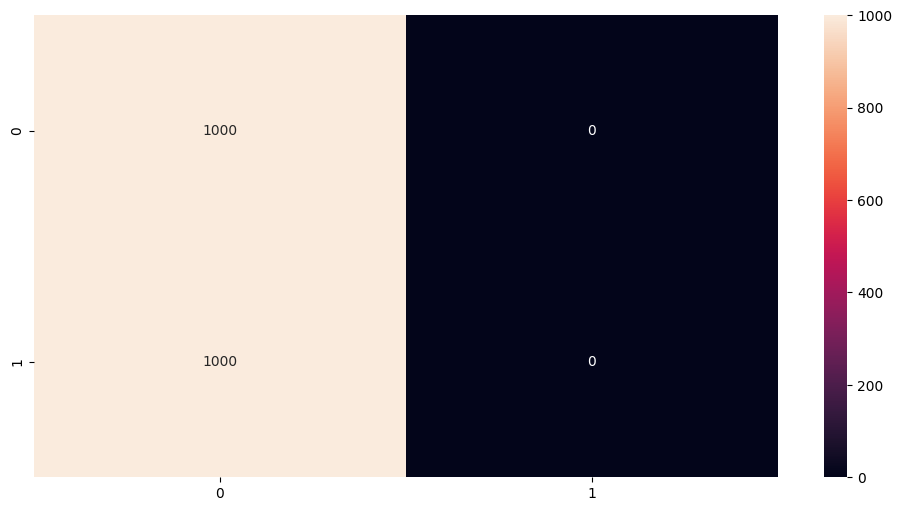

In [44]:
build_unnormalized_confusion_matrix(model, test_loader)

Checking the actual predictions

In [45]:
iterator = iter(test_loader)
images, targets = next(iterator)
logits = model(images.to(device))
print(logits)


tensor([[0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210],
        [0.0244, 0.0210]], device='cuda:0', grad_fn=<AddmmBackward0>)


The model fails to learn effectively, consistently reporting an accuracy of around 50%. It predicts the same class—"cat"—for every input, indicating that it is not capturing any meaningful patterns from the data.

While this is a simple experiment, it clearly highlights that the task is significantly more challenging than the datasets used in previous notebooks.

## Transfer Learning

The goal of transfer learning is to leverage knowledge from a model pre-trained on a large dataset and apply it to a new, often smaller, dataset.

This approach benefits from the fact that the feature extraction layers have already learned useful representations. As a result, training is typically faster and the resulting model often performs better, even with limited data.

Most pre-trained models are structured in blocks. At a high level (and in simplified terms), the early blocks act as feature extractors, capturing patterns such as edges, textures, and shapes. These features are passed through successive layers until they reach the final block, which performs the classification.

Many of these models have been trained on the ImageNet-1K dataset, and their pre-trained weights are readily available in torchvision. 

Transfer learning typically involves two phases:

- Phase 1: Freeze all blocks except the classifier. Only the classifier’s weights are updated during training.

- Phase 2: Gradually unfreeze some or all of the feature extraction blocks and fine-tune the model further.

### Creating the model



VGG16 was originally built for ImageNet, a 1000 class problem. Our dataset has only two classes: cats and dogs. To adapt the model to this dataset we are performing
Performing the following steps on VGG-16:

- load the original VGG16 with pretrained weights for the ImageNet dataset
- freeze all the weights
- replace the original classifier 

In [46]:
# load model from torchs repo, with pretrained weights from ImageNet
model = torchvision.models.vgg16(weights = torchvision.models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

n_inputs = model.classifier[0].in_features

model.classifier = torch.nn.Sequential(
    torch.nn.Linear(n_inputs, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 2)
)
model.to(device)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Training and Evaluating

In [47]:
loss_fn = torch.nn.CrossEntropyLoss()

early_stop = Early_Stopping(9, min_delta = 0.000001)
optimizer = torch.optim.Adam(model.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    

if TRAIN:
    history = train_III(model, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'vgg16_tl_{SAMPLES}')

reload = torch.load(f'vgg16_tl_{SAMPLES}_best.pt')
print(reload['epoch'])
model.load_state_dict(reload['model'])
evaluate(model, test_loader)

Epoch: 000; Loss: 0.105072; Accuracy: 96.3913;               Val Loss: 0.076148; Val Acc: 97.3044;               Elapsed time: 71.3028
Epoch: 001; Loss: 0.058717; Accuracy: 97.7391;               Val Loss: 0.095812; Val Acc: 96.5217;               Elapsed time: 70.1678
Epoch: 002; Loss: 0.051417; Accuracy: 98.0918;               Val Loss: 0.086572; Val Acc: 96.8696;               Elapsed time: 78.2625
Epoch: 003; Loss: 0.039057; Accuracy: 98.4879;               Val Loss: 0.096044; Val Acc: 96.6957;               Elapsed time: 76.1350
==> Learning rate updated:  0.001  ->  0.0001
Epoch: 004; Loss: 0.032888; Accuracy: 98.7874;               Val Loss: 0.100322; Val Acc: 97.1739;               Elapsed time: 71.3539
Epoch: 005; Loss: 0.018543; Accuracy: 99.3865;               Val Loss: 0.088356; Val Acc: 97.4348;               Elapsed time: 70.6474
Epoch: 006; Loss: 0.015373; Accuracy: 99.5217;               Val Loss: 0.087983; Val Acc: 97.5217;               Elapsed time: 73.0582
Epoch: 00

0.9754999876022339

With a test accuracy of 97.55%, this dataset clearly benefits from transfer learning from a model pretrained on ImageNet.

To be fair, ImageNet-1K already contains many dog breeds and several cat categories, so the pretrained network has seen a wide variety of cats and dogs during its original training. Although we are not reusing the classifier block, most of the discriminative features for these two species are definitely encoded in the shared feature extraction block.

In [ ]:
show_bad_preds(model, test_loader, test_loader.dataset.classes)

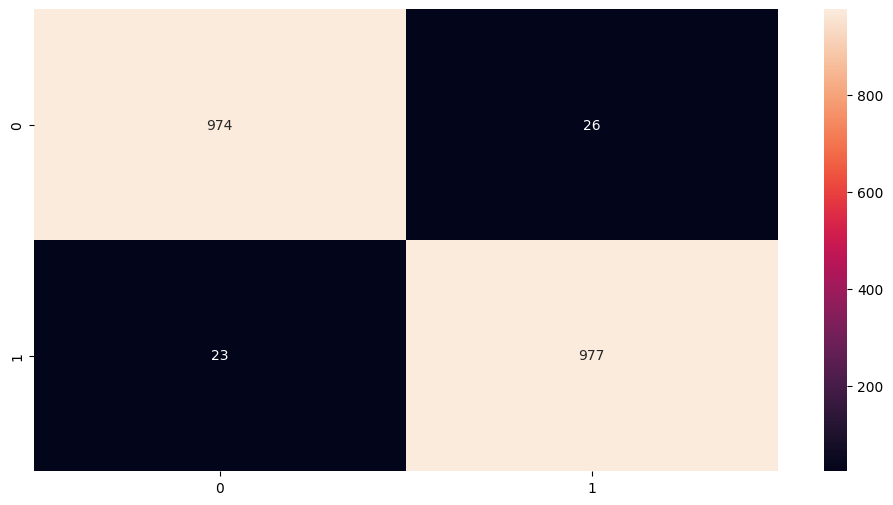

In [49]:
build_unnormalized_confusion_matrix(model, test_loader)

In [ ]:
Now were going to take it one step further, and reduce the dataset size to 2500, with 2250 images for training and 250 images for validation

In [50]:
SAMPLES =  2500
PATH_TEST_SET = f'{prefix}/test'
PATH_VAL_SET =f'{prefix}/val_{SAMPLES}'

PATH_TRAINING_SET = f'{prefix}/train_{SAMPLES}'

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = test_transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)


In [51]:
def reset_weights(model):
    @torch.no_grad()
    def _reset(m):
        if hasattr(m, "reset_parameters"):
            m.reset_parameters()
    model.apply(_reset)

reset_weights(model.classifier)    

In [57]:
loss_fn = torch.nn.CrossEntropyLoss()

early_stop = Early_Stopping(9, min_delta = 0.000001)
optimizer = torch.optim.Adam(model.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    

if TRAIN:
    history = train_III(model, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'vgg16_tl_{SAMPLES}')

reload = torch.load(f'vgg16_tl_{SAMPLES}.pt')
print(reload['epoch'])
model.load_state_dict(reload['model'])
evaluate(model, test_loader)

Epoch: 000; Loss: 0.041614; Accuracy: 98.7111;               Val Loss: 0.215612; Val Acc: 96.4000;               Elapsed time: 8.2047
Epoch: 001; Loss: 0.052092; Accuracy: 98.9333;               Val Loss: 0.192668; Val Acc: 98.4000;               Elapsed time: 7.6335
Epoch: 002; Loss: 0.032467; Accuracy: 99.0667;               Val Loss: 0.214537; Val Acc: 96.4000;               Elapsed time: 7.6866
Epoch: 003; Loss: 0.045135; Accuracy: 98.9778;               Val Loss: 0.239699; Val Acc: 97.2000;               Elapsed time: 7.5469
Epoch: 004; Loss: 0.022079; Accuracy: 99.4667;               Val Loss: 0.236499; Val Acc: 96.0000;               Elapsed time: 7.3767
==> Learning rate updated:  0.001  ->  0.0001
Epoch: 005; Loss: 0.023106; Accuracy: 99.4667;               Val Loss: 0.243977; Val Acc: 97.2000;               Elapsed time: 7.5137
Epoch: 006; Loss: 0.024855; Accuracy: 99.5556;               Val Loss: 0.108661; Val Acc: 98.0000;               Elapsed time: 7.6909
Epoch: 007; Loss

0.9735000133514404

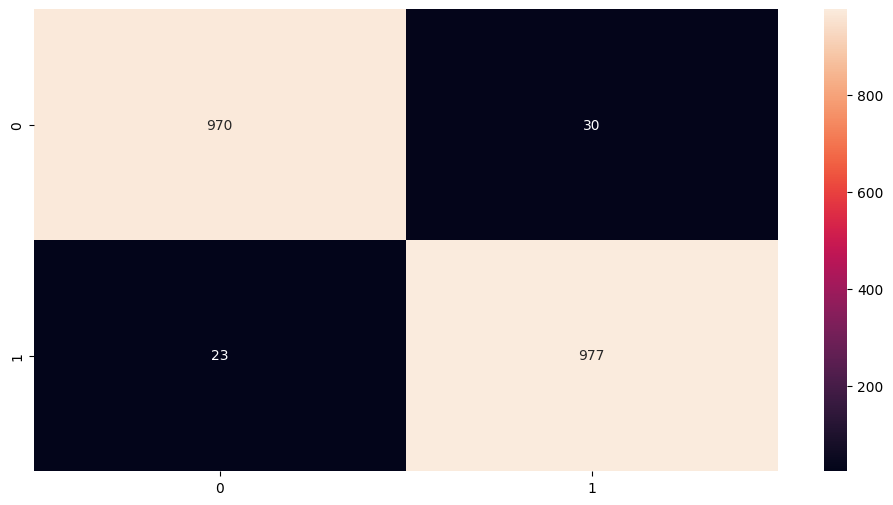

In [58]:
build_unnormalized_confusion_matrix(model, test_loader)

Now lets take it even further: 250 images 

In [60]:
SAMPLES =  250
PATH_TEST_SET = f'{prefix}/test'
PATH_VAL_SET =f'{prefix}/val_{SAMPLES}'

PATH_TRAINING_SET = f'{prefix}/train_{SAMPLES}'

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = test_transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)

reset_weights(model.classifier)  

early_stop = Early_Stopping(9, min_delta = 0.000001)
optimizer = torch.optim.Adam(model.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    

if TRAIN:
    history = train_III(model, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'vgg16_tl_{SAMPLES}')

reload = torch.load(f'vgg16_tl_{SAMPLES}.pt')
print(reload['epoch'])
model.load_state_dict(reload['model'])
evaluate(model, test_loader)

Epoch: 000; Loss: 1.239125; Accuracy: 80.0885;               Val Loss: 0.612745; Val Acc: 91.6667;               Elapsed time: 1.0367
Epoch: 001; Loss: 0.111835; Accuracy: 96.9027;               Val Loss: 0.493320; Val Acc: 91.6667;               Elapsed time: 0.7273
Epoch: 002; Loss: 0.015469; Accuracy: 98.6726;               Val Loss: 0.204459; Val Acc: 95.8333;               Elapsed time: 0.7850
Epoch: 003; Loss: 0.000740; Accuracy: 100.0000;               Val Loss: 0.111302; Val Acc: 91.6667;               Elapsed time: 0.7471
Epoch: 004; Loss: 0.096336; Accuracy: 99.5575;               Val Loss: 0.130013; Val Acc: 95.8333;               Elapsed time: 0.7908
Epoch: 005; Loss: 0.000812; Accuracy: 100.0000;               Val Loss: 0.205659; Val Acc: 95.8333;               Elapsed time: 0.7918
Epoch: 006; Loss: 0.000232; Accuracy: 100.0000;               Val Loss: 0.159792; Val Acc: 95.8333;               Elapsed time: 0.7608
==> Learning rate updated:  0.001  ->  0.0001
Epoch: 007; L

0.9620000123977661

To end this experiment, lets take it to the extreme: 20 images 

In [61]:
SAMPLES =  25
PATH_TEST_SET = f'{prefix}/test'
PATH_VAL_SET =f'{prefix}/val_{SAMPLES}'

PATH_TRAINING_SET = f'{prefix}/train_{SAMPLES}'

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = test_transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)

reset_weights(model.classifier)  

early_stop = Early_Stopping(9, min_delta = 0.000001)
optimizer = torch.optim.Adam(model.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    

if TRAIN:
    history = train_III(model, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'vgg16_tl_{SAMPLES}')

reload = torch.load(f'vgg16_tl_{SAMPLES}.pt')
print(reload['epoch'])
model.load_state_dict(reload['model'])
evaluate(model, test_loader)

Epoch: 000; Loss: 1.160084; Accuracy: 62.5000;               Val Loss: 0.000595; Val Acc: 100.0000;               Elapsed time: 0.3605
Epoch: 001; Loss: 0.558401; Accuracy: 91.6667;               Val Loss: 0.000001; Val Acc: 100.0000;               Elapsed time: 0.1413
Epoch: 002; Loss: 0.045847; Accuracy: 95.8333;               Val Loss: 0.000015; Val Acc: 100.0000;               Elapsed time: 0.1619
Epoch: 003; Loss: 0.000004; Accuracy: 100.0000;               Val Loss: 0.000165; Val Acc: 100.0000;               Elapsed time: 0.1606
Epoch: 004; Loss: 0.014682; Accuracy: 100.0000;               Val Loss: 0.000429; Val Acc: 100.0000;               Elapsed time: 0.1479
==> Learning rate updated:  0.001  ->  0.0001
Epoch: 005; Loss: 0.003341; Accuracy: 100.0000;               Val Loss: 0.000273; Val Acc: 100.0000;               Elapsed time: 0.1678
Epoch: 006; Loss: 0.000000; Accuracy: 100.0000;               Val Loss: 0.000257; Val Acc: 100.0000;               Elapsed time: 0.1596
Epoch

0.8510000109672546

## Conclusion

The results clearly show the advantages of transfer learning in this setting. When training from scratch, the model effectively collapsed to predicting every image as a cat. With transfer learning, preserving the classification backbone we obtained a much stronger performance, even with very small training sets.

In particular, with only 25 labeled images the transfer‑learned model still achieves a much better test accuracy than the from‑scratch model, and with a few hundred or a few thousand images it nearly matches the performance obtained with the full 23000‑image training set.

| Training images | Test accuracy (%) |
|-----------------|-------------------|
| 23000           | 97.55             |
| 2500            | 97.35             |
| 250             | 96.20             |
| 25              | 85.10             |